 # Exploring the Knowledge Graph with SPARQL


In [1]:
from rdflib import Graph
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

g = Graph(store="Oxigraph")
g.parse("data/SciGraph4UNSDG.ttl", format="ox-turtle")
print(f"Number of triples in the graph: {len(g)}")

prefixes = """
PREFIX   bibo: <http://purl.org/ontology/bibo/>
PREFIX   dct: <http://purl.org/dc/terms/>
PREFIX   foaf: <http://xmlns.com/foaf/0.1/>
PREFIX   org: <http://www.w3.org/ns/org#>
PREFIX   owl: <http://www.w3.org/2002/07/owl#>
PREFIX   prov: <http://www.w3.org/ns/prov#>
PREFIX   rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#>
PREFIX   rdfs: <http://www.w3.org/2000/01/rdf-schema#>
PREFIX   schema1: <http://schema.org/>
PREFIX   sci: <http://scigraph4unsdg.org/>
PREFIX   scitax: <http://scigraph4unsdg.org/taxonomy#>
PREFIX   sdgo: <http://metadata.un.org/sdg/ontology#>
PREFIX   skos: <http://www.w3.org/2004/02/skos/core#>
PREFIX   unsdg: <http://metadata.un.org/sdg/>
PREFIX   wd: <https://www.wikidata.org/wiki/>
PREFIX   xsd: <http://www.w3.org/2001/XMLSchema#>
"""

Number of triples in the graph: 1516649


### Schema Exploration

In [2]:
# Count all node types in the graph
# Gives a quick census of how many instances exist per class.
# -----------------------------------------------------------------------
result = g.query(prefixes +"""

SELECT ?class (COUNT(?instance) AS ?count)
WHERE {
  ?instance a ?class .
}
GROUP BY ?class
ORDER BY DESC(?count)
""")
pd.DataFrame(result.bindings)

,class,count
0,http://scigraph4unsdg.org/taxonomy#SDGAssignment,25550
1,http://scigraph4unsdg.org/taxonomy#EvidenceCon...,6695
2,http://metadata.un.org/sdg/ontology#Series,708
3,http://schema.org/FundingAgency,440
4,http://metadata.un.org/sdg/ontology#Indicator,251
5,http://purl.org/ontology/bibo/Document,200
6,http://scigraph4unsdg.org/taxonomy#Classificat...,200
7,http://metadata.un.org/sdg/ontology#Target,169
8,http://www.w3.org/2004/02/skos/core#Concept,130
9,http://purl.org/ontology/bibo/Journal,85


In [3]:
# Count all named properties used in the graph (schema fingerprint)
# -----------------------------------------------------------------------
result = g.query(prefixes +"""

SELECT ?property (COUNT(*) AS ?tripleCount)
WHERE {
    ?s ?property ?o .
    FILTER(?property != rdf:type)
}
GROUP BY ?property
ORDER BY DESC(?tripleCount)

""")
pd.DataFrame(result.bindings)

,property,tripleCount
0,http://www.w3.org/ns/prov#used,1041207
1,http://scigraph4unsdg.org/taxonomy#quoteContext,37898
2,http://scigraph4unsdg.org/taxonomy#toTarget,29854
3,http://scigraph4unsdg.org/taxonomy#hasAssignme...,29854
4,http://scigraph4unsdg.org/taxonomy#toGoal,29816
...,...,...
61,http://www.w3.org/2002/07/owl#inverseOf,31
62,http://purl.org/dc/terms/description,17
63,http://www.w3.org/2002/07/owl#equivalentClass,13
64,http://www.w3.org/2000/01/rdf-schema#subProper...,8


In [4]:
# Verify the SDG hierarchy is complete (Goals → Targets → Indicators → Series)
# Shows how many Targets, Indicators, and Series each Goal contains.
# Missing entries here reveal structural gaps in the loaded SDG ontology data.
# -----------------------------------------------------------------------
result = g.query(prefixes +"""
SELECT ?goal (COUNT(DISTINCT ?target) AS ?targetCount) (COUNT(DISTINCT ?indicator) AS ?indicatorCount) (COUNT(DISTINCT ?series) AS ?seriesCount)
WHERE {
    ?goal a sdgo:Goal ;
           sdgo:hasTarget ?target .
   ?target a sdgo:Target ;
            sdgo:hasIndicator ?indicator .
   ?indicator a sdgo:Indicator ;
             sdgo:hasSeries ?series .
}
GROUP BY ?goal
# ORDER BY ASC(?targetCount)

""")
pd.DataFrame(result.bindings)

,goal,targetCount,indicatorCount,seriesCount
0,http://metadata.un.org/sdg/8,12,17,34
1,http://metadata.un.org/sdg/10,10,14,27
2,http://metadata.un.org/sdg/1,7,13,59
3,http://metadata.un.org/sdg/4,10,12,39
4,http://metadata.un.org/sdg/5,9,13,47
5,http://metadata.un.org/sdg/13,5,8,36
6,http://metadata.un.org/sdg/15,12,14,35
7,http://metadata.un.org/sdg/7,5,6,6
8,http://metadata.un.org/sdg/3,13,28,42
9,http://metadata.un.org/sdg/16,12,24,81


### Core Gap Analysis: Which SDGs are most and least addressed by the works in the graph?

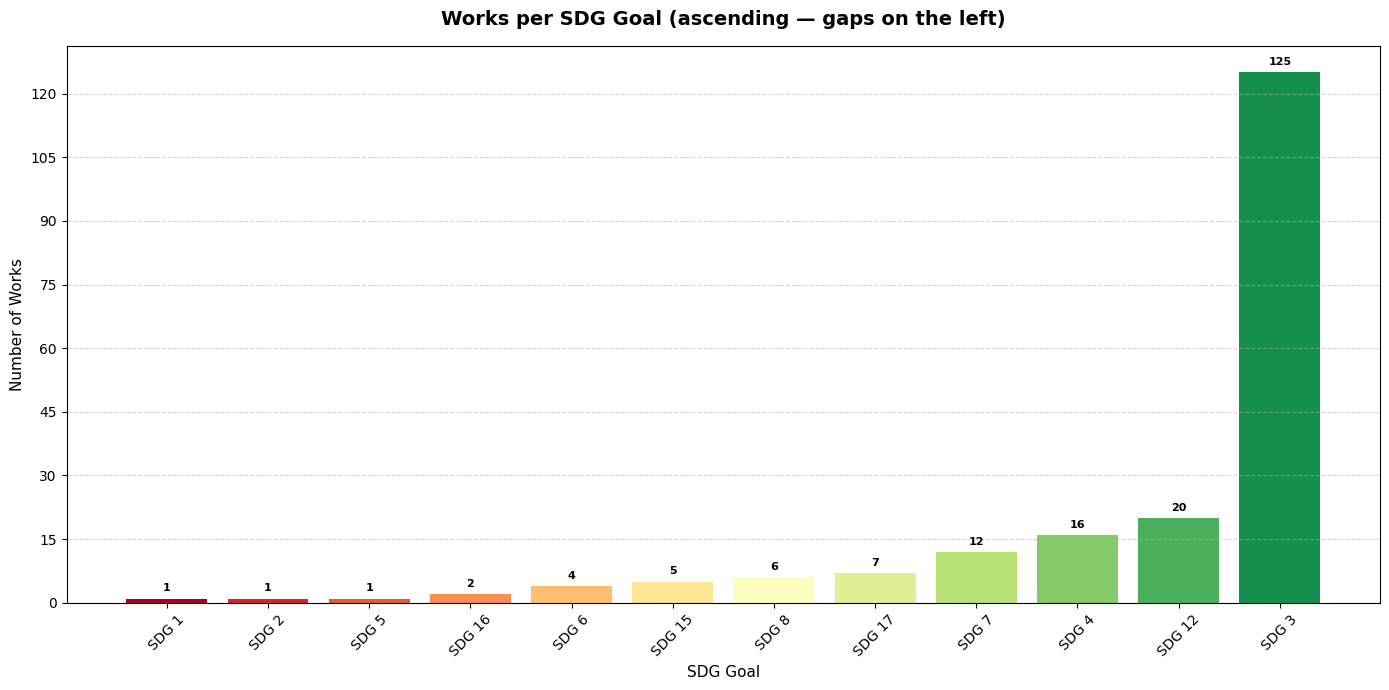

In [5]:
# Works per SDG Goal — top-level coverage overview
# The primary gap analysis query: which Goals have the least research attention?
# -----------------------------------------------------------------------
result = g.query(prefixes +"""

SELECT ?goal ?goalLabel (COUNT(DISTINCT ?work) AS ?workCount)
WHERE {
    ?work  rdf:type        bibo:Document ;
           scitax:addressesGoal ?goal .
    ?goal  skos:prefLabel      ?goalLabel .
}
GROUP BY ?goal ?goalLabel
ORDER BY ASC(?workCount)   # ascending: gaps appear at the top

""")

df = pd.DataFrame(result.bindings)
df.columns = ["goal", "goalLabel", "workCount"]
df["workCount"] = df["workCount"].astype(int)

# Extract short Goal number from URI  e.g. ".../sdg/3" → "SDG 3"
df["goalShort"] = df["goal"].astype(str).str.extract(r'/sdg/(\d+)$')[0].apply(lambda x: f"SDG {x}")

# Sort ascending (gaps at top → left in bar chart)
df = df.sort_values("workCount", ascending=True).reset_index(drop=True)

# --- Plot ---
plt.style.use("default")
fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

colors = plt.cm.RdYlGn([i / len(df) for i in range(len(df))])  # red=fewest → green=most

bars = ax.bar(df["goalShort"], df["workCount"], color=colors, linewidth=0.6)

# Value labels on top of each bar
for bar, val in zip(bars, df["workCount"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(df["workCount"]) * 0.01,
        str(val),
        ha="center", va="bottom", fontsize=8, fontweight="bold"
    )

ax.set_title("Works per SDG Goal (ascending — gaps on the left)", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("SDG Goal", fontsize=11)
ax.set_ylabel("Number of Works", fontsize=11)
ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("works_per_sdg_goal.png", dpi=150, bbox_inches="tight")
plt.show()


In [6]:
# Works per SDG Target — finer-grained coverage
# Reveals which specific Targets within Goals are under-researched.
# -----------------------------------------------------------------------
result = g.query(prefixes +"""

SELECT ?goal ?target (COUNT(DISTINCT ?work) AS ?workCount)
WHERE {
    ?work   rdf:type           bibo:Document ;
            scitax:addressesTarget ?target .
    ?target skos:prefLabel         ?targetLabel ;
            sdgo:isTargetOf ?goal .
    ?goal   skos:prefLabel        ?goalLabel .
}
GROUP BY ?goal ?goalLabel ?target ?targetLabel
ORDER BY ASC(?workCount)

""")
pd.DataFrame(result.bindings)

,goal,target,workCount
0,http://metadata.un.org/sdg/2,http://metadata.un.org/sdg/2.b,1
1,http://metadata.un.org/sdg/1,http://metadata.un.org/sdg/1.5,1
2,http://metadata.un.org/sdg/5,http://metadata.un.org/sdg/5.1,1
3,http://metadata.un.org/sdg/5,http://metadata.un.org/sdg/5.5,1
4,http://metadata.un.org/sdg/17,http://metadata.un.org/sdg/17.2,1
...,...,...,...
90,http://metadata.un.org/sdg/3,http://metadata.un.org/sdg/3.1,116
91,http://metadata.un.org/sdg/3,http://metadata.un.org/sdg/3.2,116
92,http://metadata.un.org/sdg/3,http://metadata.un.org/sdg/3.9,117
93,http://metadata.un.org/sdg/3,http://metadata.un.org/sdg/3.4,125


In [7]:
# SDG Targets with ZERO linked works (absolute gaps)
# These are targets that exist in the SDG hierarchy but have no research
# mapped to them at all — the hardest gaps to fill.
# -----------------------------------------------------------------------
result = g.query(prefixes +"""

SELECT ?goal ?target
WHERE {
    ?target a sdgo:Target ;
            skos:prefLabel         ?targetLabel ;
            sdgo:isTargetOf ?goal .
    ?goal   skos:prefLabel         ?goalLabel .
    FILTER NOT EXISTS {
        ?target scitax:targetAddressedBy ?work .
    }
}
""")
pd.DataFrame(result.bindings)

,goal,target
0,http://metadata.un.org/sdg/11,http://metadata.un.org/sdg/11.5
1,http://metadata.un.org/sdg/13,http://metadata.un.org/sdg/13.1
2,http://metadata.un.org/sdg/9,http://metadata.un.org/sdg/9.4
3,http://metadata.un.org/sdg/11,http://metadata.un.org/sdg/11.b
4,http://metadata.un.org/sdg/11,http://metadata.un.org/sdg/11.6
...,...,...
69,http://metadata.un.org/sdg/10,http://metadata.un.org/sdg/10.b
70,http://metadata.un.org/sdg/10,http://metadata.un.org/sdg/10.3
71,http://metadata.un.org/sdg/10,http://metadata.un.org/sdg/10.2
72,http://metadata.un.org/sdg/10,http://metadata.un.org/sdg/10.1


In [8]:
# SDG Indicators with ZERO linked works (finest-grained absolute gaps)
# Same as above but at the Indicator level — the most actionable gap signal
# for portfolio managers who want to commission targeted research.
# -----------------------------------------------------------------------
result = g.query(prefixes +"""
SELECT ?goal ?target ?indicatorLabel
WHERE {
    ?indicator a              sdgo:Indicator ;
               skos:prefLabel           ?indicatorLabel ;
               sdgo:isIndicatorOf ?target .
    ?target    skos:prefLabel             ?targetLabel ;
               sdgo:isTargetOf    ?goal .
    ?goal      skos:prefLabel             ?goalLabel .
    FILTER NOT EXISTS {
        ?work scitax:addressesIndicator ?indicator .
    }
}
ORDER BY ?goalLabel ?targetLabel ?indicatorLabel
""")
pd.DataFrame(result.bindings)

,goal,target,indicatorLabel
0,http://metadata.un.org/sdg/5,http://metadata.un.org/sdg/5.2,Proportion of women and girls aged 15 years an...
1,http://metadata.un.org/sdg/5,http://metadata.un.org/sdg/5.6,Number of countries with laws and regulations ...
2,http://metadata.un.org/sdg/5,http://metadata.un.org/sdg/5.a,(a) Proportion of total agricultural populatio...
3,http://metadata.un.org/sdg/5,http://metadata.un.org/sdg/5.a,Proportion of countries where the legal framew...
4,http://metadata.un.org/sdg/9,http://metadata.un.org/sdg/9.4,CO2 emission per unit of value added
...,...,...,...
159,http://metadata.un.org/sdg/13,http://metadata.un.org/sdg/13.2,Total greenhouse gas emissions per year
160,http://metadata.un.org/sdg/13,http://metadata.un.org/sdg/13.b,Number of least developed countries and small ...
161,http://metadata.un.org/sdg/13,http://metadata.un.org/sdg/13.1,Number of countries that adopt and implement n...
162,http://metadata.un.org/sdg/13,http://metadata.un.org/sdg/13.1,"Number of deaths, missing persons and directly..."


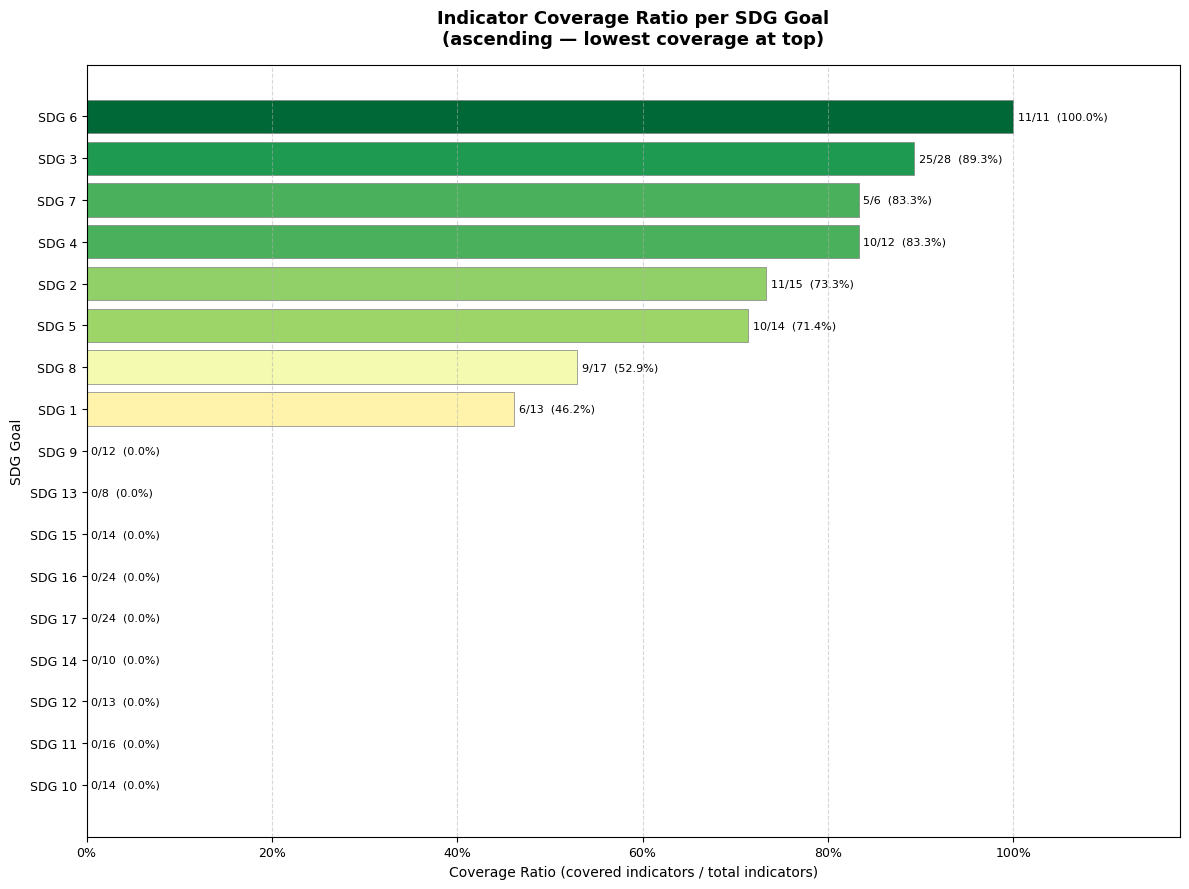

In [9]:
# Coverage ratio per Goal (works vs total possible indicators)
# A normalised gap score: Goals closer to 0 are more under-covered relative to how many indicators they contain.
# Note: xsd:double() used for division — Oxigraph does not support xsd:decimal() as a cast function.
# COALESCE handles Goals with zero covered indicators (inner join would drop them).
result = g.query(prefixes + """
SELECT ?goal ?goalLabel
       ?totalIndicators
       (COALESCE(?coveredIndicators, 0) AS ?covered)
       (xsd:double(COALESCE(?coveredIndicators, 0)) / xsd:double(?totalIndicators) AS ?coverageRatio)
WHERE {
    {
        SELECT ?goal (COUNT(DISTINCT ?indicator) AS ?totalIndicators)
        WHERE {
            ?goal      a             sdgo:Goal ;
                       sdgo:hasTarget    ?target .
            ?target    sdgo:hasIndicator ?indicator .
        }
        GROUP BY ?goal
    }
    OPTIONAL {
        SELECT ?goal (COUNT(DISTINCT ?indicator) AS ?coveredIndicators)
        WHERE {
            ?work  scitax:addressesIndicator ?indicator .
            ?indicator sdgo:isIndicatorOf ?target .
            ?target    sdgo:isTargetOf    ?goal .
        }
        GROUP BY ?goal
    }
    ?goal skos:prefLabel ?goalLabel .
    FILTER(LANG(?goalLabel) = "en")
}
ORDER BY ASC(?coverageRatio)
""")

df_cov = pd.DataFrame(result.bindings)
df_cov.columns = ["goal", "goalLabel", "totalIndicators", "covered", "coverageRatio"]
df_cov["totalIndicators"] = df_cov["totalIndicators"].astype(int)
df_cov["covered"]         = df_cov["covered"].astype(int)
df_cov["coverageRatio"]   = df_cov["coverageRatio"].astype(float)

# Short SDG label from URI e.g. ".../sdg/3" → "SDG 3"
df_cov["goalShort"] = df_cov["goal"].astype(str).str.extract(r'/sdg/(\d+)$')[0].apply(lambda x: f"SDG {x}")

# Sort ascending (lowest coverage at top)
df_cov = df_cov.sort_values("coverageRatio", ascending=True).reset_index(drop=True)

# --- Plot ---
plt.style.use("default")
fig, ax = plt.subplots(figsize=(12, 9))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

colors = plt.cm.RdYlGn(df_cov["coverageRatio"].values)  # colour mapped to actual ratio

bars = ax.barh(df_cov["goalShort"], df_cov["coverageRatio"], color=colors, edgecolor="grey", linewidth=0.5)

# Annotate each bar: "covered / total (xx.x%)"
for bar, covered, total, ratio in zip(bars, df_cov["covered"], df_cov["totalIndicators"], df_cov["coverageRatio"]):
    ax.text(
        bar.get_width() + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{covered}/{total}  ({ratio * 100:.1f}%)",
        va="center", ha="left", fontsize=8
    )

ax.set_xlim(0, 1.18)
ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.set_title("Indicator Coverage Ratio per SDG Goal\n(ascending — lowest coverage at top)",
             fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Coverage Ratio (covered indicators / total indicators)", fontsize=10)
ax.set_ylabel("SDG Goal", fontsize=10)
ax.grid(axis="x", linestyle="--", alpha=0.5)
ax.tick_params(axis="both", labelsize=9)

plt.tight_layout()
plt.savefig("indicator_coverage_ratio.png", dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

### Topic Based Discovery

In [10]:
# Most common topics linked to each SDG Goal
# This reveals the intellectual vocabulary of each Goal — useful for
# SDG-aware recommender systems and search query expansion.
# -----------------------------------------------------------------------
result = g.query(prefixes + """
SELECT ?goal ?topicName (COUNT(DISTINCT ?work) AS ?workCount)
WHERE {
    ?work  a bibo:Document ;
           scitax:addressesGoal ?goal ;
           foaf:primaryTopic ?topic .
    ?goal  skos:prefLabel ?goalLabel .
    ?topic skos:prefLabel ?topicName .
}
GROUP BY ?goal ?goalLabel ?topic ?topicName
ORDER BY ?goalLabel DESC(?workCount)

""")
pd.DataFrame(result.bindings)

,goal,topicName,workCount
0,http://metadata.un.org/sdg/5,"Genetics, Aging, and Longevity in Model Organisms",1
1,http://metadata.un.org/sdg/2,Autophagy in Disease and Therapy,1
2,http://metadata.un.org/sdg/1,Genomics and Phylogenetic Studies,1
3,http://metadata.un.org/sdg/7,Atmospheric and Environmental Gas Dynamics,2
4,http://metadata.un.org/sdg/7,Atmospheric chemistry and aerosols,2
...,...,...,...
147,http://metadata.un.org/sdg/17,Genomics and Phylogenetic Studies,1
148,http://metadata.un.org/sdg/17,Forest Insect Ecology and Management,1
149,http://metadata.un.org/sdg/17,Algorithms and Data Compression,1
150,http://metadata.un.org/sdg/17,Microbial Community Ecology and Physiology,1


In [11]:
# Topics that span MULTIPLE Goals (cross-cutting research themes)
# This is high-value for portfolio analytics: these topics represent research
# that simultaneously addresses several SDGs — high leverage for funders.
# -----------------------------------------------------------------------
result = g.query(prefixes + """
SELECT ?topicName (COUNT(DISTINCT ?goal) AS ?goalsCovered) (COUNT(DISTINCT ?work) AS ?workCount)
WHERE {
    ?work  a          bibo:Document ;
           scitax:addressesGoal  ?goal ;
           foaf:primaryTopic ?topic .
    ?topic skos:prefLabel       ?topicName .
}
GROUP BY ?topic ?topicName
HAVING (COUNT(DISTINCT ?goal) > 1)
ORDER BY DESC(?goalsCovered) DESC(?workCount)

""")
pd.DataFrame(result.bindings)

,topicName,goalsCovered,workCount
0,Genomics and Phylogenetic Studies,8,16
1,Cancer-related molecular mechanisms research,3,4
2,Atmospheric and Environmental Gas Dynamics,3,4
3,Genomics and Chromatin Dynamics,2,5
4,Gut microbiota and health,2,4
5,Autophagy in Disease and Therapy,2,4
6,Single-cell and spatial transcriptomics,2,3
7,Cell Image Analysis Techniques,2,2
8,Advanced Proteomics Techniques and Applications,2,2
9,Bioinformatics and Genomic Networks,2,2


### Funder Portfolio Analysis

In [12]:
# Funder coverage per SDG Goal
# Core query for funder portfolio dashboards.
# -----------------------------------------------------------------------
result = g.query(prefixes + """

SELECT ?funderName ?goal (COUNT(DISTINCT ?work) AS ?workCount)
WHERE {
    ?work   a          bibo:Document ;
            scitax:addressesGoal  ?goal ;
            foaf:fundedBy     ?funder .
    ?funder schema1:name       ?funderName .
    ?goal   skos:prefLabel        ?goalLabel .
}
GROUP BY ?funder ?funderName ?goal ?goalLabel
ORDER BY ?funderName DESC(?workCount)

                 """)
pd.DataFrame(result.bindings)

,funderName,goal,workCount
0,Aarhus Universitet,http://metadata.un.org/sdg/3,1
1,Agence Nationale de Recherches sur le Sida et ...,http://metadata.un.org/sdg/3,1
2,Agence Nationale de la Recherche,http://metadata.un.org/sdg/3,1
3,Agencia Estatal de Investigación,http://metadata.un.org/sdg/3,2
4,Agricultural Research Service,http://metadata.un.org/sdg/4,1
...,...,...,...
540,Youth Innovation Promotion Association of the ...,http://metadata.un.org/sdg/3,1
541,Zhongnan Hospital of Wuhan University,http://metadata.un.org/sdg/3,1
542,École Polytechnique Fédérale de Lausanne,http://metadata.un.org/sdg/3,1
543,Österreichischen Akademie der Wissenschaften,http://metadata.un.org/sdg/3,1


In [13]:
# Funders whose portfolio is concentrated on a single SDG
# opportunity; useful for portfolio diversification advice.
# -----------------------------------------------------------------------
result = g.query(prefixes + """

SELECT ?funderName (COUNT(DISTINCT ?goal) AS ?goalsCovered) (COUNT(DISTINCT ?work) AS ?totalWorks)
WHERE {
    ?work   rdf:type         bibo:Document ;
            scitax:addressesGoal ?goal ;
            foaf:fundedBy    ?funder .
    ?funder schema1:name      ?funderName .
}
GROUP BY ?funder ?funderName
HAVING (COUNT(DISTINCT ?goal) = 1)
ORDER BY DESC(?totalWorks)

                 """)
pd.DataFrame(result.bindings)

,funderName,goalsCovered,totalWorks
0,National Cancer Institute,1,13
1,National Institute for Health and Care Research,1,8
2,GlaxoSmithKline,1,8
3,Instituto de Salud Carlos III,1,8
4,Eli Lilly and Company,1,6
...,...,...,...
369,Washington University School of Medicine in St...,1,1
370,U.S. Environmental Protection Agency,1,1
371,National Institute of Academic Anaesthesia,1,1
372,Regione Autonoma della Sardegna,1,1


### SDG-Specific Discoveries

In [14]:
# All works addressing a specific Target (parameterisable template)
# Replace "1.1" with any target ID to explore coverage of a specific target.
# -----------------------------------------------------------------------
result = g.query(prefixes + """
SELECT ?work ?title ?year ?topicName
WHERE {
    BIND(<http://metadata.un.org/sdg/3.1> AS ?target)
    ?work   a                  bibo:Document ;
            dct:title          ?title ;
            scitax:addressesTarget ?target ;
            schema1:copyrightYear  ?year .
    OPTIONAL {
        ?work  foaf:primaryTopic ?topic .
        ?topic skos:prefLabel    ?topicName .
    }
}
ORDER BY DESC(?year)
""")

pd.DataFrame(result.bindings)

,work,title,year,topicName
0,https://openalex.org/W4392145873,Two new Later Stone Age sites from the Final P...,2024,Diet and metabolism studies
1,https://openalex.org/W4285390610,Multimorbidity,2022,Chronic Disease Management Strategies
2,https://openalex.org/W4213436352,Mental Health Surveillance Among Children — Un...,2022,Child and Adolescent Psychosocial and Emotiona...
3,https://openalex.org/W3164570271,"Global epidemiology, health burden and effecti...",2021,Blood Pressure and Hypertension Studies
4,https://openalex.org/W3049325061,A dynamic COVID-19 immune signature includes a...,2020,COVID-19 Clinical Research Studies
...,...,...,...,...
111,https://openalex.org/W1980475208,Chemokine receptor CXCR4 downregulated by von ...,2003,Chemokine receptors and signaling
112,https://openalex.org/W2039403622,High prevalence of diabetes and impaired gluco...,2001,"Diabetes, Cardiovascular Risks, and Lipoproteins"
113,https://openalex.org/W2103017472,Gene Ontology: tool for the unification of bio...,2000,Bioinformatics and Genomic Networks
114,https://openalex.org/W2124415162,"BMP-7 is an inducer of nephrogenesis, and is a...",1995,Renal and related cancers


### Provenance queries

In [15]:
# These queries traverse the PROV-O layer added in Part 6 of the ontology.
# They answer questions that are impossible without reification:
#   - WHY was a work linked to an SDG? (what evidence was used?)
#   - HOW confident should we be? (score + concept weight together)
#   - WHICH vocabulary terms drove the most SDG assignments across the corpus?
# Full traversal path for reference:
#   bibo:Document
#       └── openalex:hasAssignment
#               └── openalex:SDGAssignment
#                       ├── openalex:toGoal / toTarget / toIndicator / toSeries
#                       │       └── unsdgio:Goal / Target / Indicator / Series
#                       ├── prov:wasGeneratedBy
#                       │       └── openalex:ClassificationActivity
#                       │               ├── prov:used  ──► bibo:Document
#                       │               └── prov:startedAtTime
#                       └── prov:used
#                               └── openalex:EvidenceConcept
#                                       ├── openalex:conceptLabel
#                                       ├── openalex:conceptWeight
#                                       ├── openalex:matchedPhrase
#                                       ├── openalex:matchContext
#                                       └── skos:exactMatch ──► EuroVoc / UNBIS URI

In [16]:
# Full evidence trail for a single work
# Change the URI inside BIND() to inspect any work in your corpus.
# -----------------------------------------------------------------------
response = g.query(prefixes + """
SELECT ?work
       ?goal
       ?target
       ?series
       ?score
       ?conceptLabel
       ?conceptWeight
       ?matchedPhrase
       ?quoteContext
       ?vocabURI
       ?classifiedAt
WHERE {
    BIND(<https://openalex.org/W2897109701> AS ?work)

    ?work       scitax:hasAssignment   ?assignment .

    ?assignment scitax:toGoal          ?goal ;
                scitax:toTarget        ?target ;
                scitax:toSeries        ?series ;
                scitax:relevanceScore  ?score ;
                prov:wasGeneratedBy    ?activity ;
                prov:used              ?concept .

    ?activity   prov:wasGeneratedAtTime  ?classifiedAt .

    ?concept    schema1:name             ?conceptLabel ;
                scitax:conceptWeight     ?conceptWeight .

    OPTIONAL { ?concept scitax:matchedPhrase ?matchedPhrase }
    OPTIONAL { ?concept scitax:quoteContext  ?quoteContext  }
    OPTIONAL { ?concept skos:exactMatch      ?vocabURI }
}
ORDER BY DESC(?score) DESC(?conceptWeight)
""")
pd.DataFrame(response.bindings)


,work,goal,target,series,score,conceptLabel,conceptWeight,matchedPhrase,quoteContext,vocabURI,classifiedAt
0,https://openalex.org/W2897109701,http://metadata.un.org/sdg/3,http://metadata.un.org/sdg/3.3,http://metadata.un.org/sdg/SH_TBS_INCID,48.1,HEALTH POLICY,5,health,journalsadolescent health medicine and therape...,http://metadata.un.org/thesaurus/1002838,2026-03-10T23:20:32.973528+00:00
1,https://openalex.org/W2897109701,http://metadata.un.org/sdg/3,http://metadata.un.org/sdg/3.3,http://metadata.un.org/sdg/SH_HIV_INCD,48.1,HEALTH POLICY,5,health,and adherencepatient related outcome measuresp...,http://eurovoc.europa.eu/2479,2026-03-10T23:20:32.973528+00:00
2,https://openalex.org/W2897109701,http://metadata.un.org/sdg/3,http://metadata.un.org/sdg/3.3,http://metadata.un.org/sdg/SH_STA_MALR,48.1,HEALTH POLICY,5,health,risk managementvaccine development and therapy...,http://metadata.un.org/thesaurus/1002838,2026-03-10T23:20:32.973528+00:00
3,https://openalex.org/W2897109701,http://metadata.un.org/sdg/3,http://metadata.un.org/sdg/3.3,http://metadata.un.org/sdg/SH_STA_MALR,48.1,HEALTH POLICY,5,health,risk managementvaccine development and therapy...,http://eurovoc.europa.eu/2479,2026-03-10T23:20:32.973528+00:00
4,https://openalex.org/W2897109701,http://metadata.un.org/sdg/3,http://metadata.un.org/sdg/3.3,http://metadata.un.org/sdg/SH_STA_MALR,48.1,HEALTH POLICY,5,health,review guidelinescollectionshot topicslatest a...,http://metadata.un.org/thesaurus/1002838,2026-03-10T23:20:32.973528+00:00
...,...,...,...,...,...,...,...,...,...,...,...
3251,https://openalex.org/W2897109701,http://metadata.un.org/sdg/4,http://metadata.un.org/sdg/4.5,http://metadata.un.org/sdg/SE_GPI_TRATEA,1.4857142857142858,HEALTH CARE,1,health care,journalsadolescent health medicine and therape...,http://eurovoc.europa.eu/5899,2026-03-10T23:20:32.973528+00:00
3252,https://openalex.org/W2897109701,http://metadata.un.org/sdg/4,http://metadata.un.org/sdg/4.5,http://metadata.un.org/sdg/SE_GPI_PART,1.4857142857142858,BIODIVERSITY,1,biodiversity,in biochemistryresearch and reports in biodive...,http://eurovoc.europa.eu/5463,2026-03-10T23:20:32.973528+00:00
3253,https://openalex.org/W2897109701,http://metadata.un.org/sdg/4,http://metadata.un.org/sdg/4.5,http://metadata.un.org/sdg/SE_GPI_REAACH,1.4857142857142858,DRUGS OF ABUSE,1,drugs,research and reviewsopen access surgeryorphan ...,http://metadata.un.org/thesaurus/1001788,2026-03-10T23:20:32.973528+00:00
3254,https://openalex.org/W2897109701,http://metadata.un.org/sdg/4,http://metadata.un.org/sdg/4.5,http://metadata.un.org/sdg/SE_GPI_REAACH,1.4857142857142858,BIODIVERSITY,1,biodiversity,in biochemistryresearch and reports in biodive...,http://eurovoc.europa.eu/5463,2026-03-10T23:20:32.973528+00:00


In [17]:
# Concept term reliability — which EvidenceConcepts most consistently
#      drive high-confidence SDG assignments across the whole corpus?
# -----------------------------------------------------------------------
# This tells you which vocabulary terms the classifier trusts most.
# A concept that appears across many high-scoring assignments is a reliable
# SDG signal; one that appears only in low-scoring assignments may be noise.
#
# Practical use: if a concept with a UNBIS URI (UN-specific vocabulary)
# drives high scores, that is stronger evidence of genuine SDG relevance
# than a generic EuroVoc term like "COMPUTER" appearing incidentally.
# -----------------------------------------------------------------------
response = g.query(prefixes + """
SELECT
       ?conceptLabel
       ?vocabURI
       (COUNT(DISTINCT ?assignment) AS ?timesUsedAsEvidence)
       (ROUND(AVG(?score) * 1000) / 1000 AS ?avgAssignmentScore)
       (MAX(?conceptWeight)              AS ?maxConceptWeight)
       (COUNT(DISTINCT ?goal)            AS ?distinctGoalsEvidenced)
WHERE {
    ?assignment a scitax:SDGAssignment ;
                scitax:relevanceScore ?score ;
                scitax:toGoal ?goal ;
                prov:used ?concept .

    ?concept    schema1:name       ?conceptLabel ;
                scitax:conceptWeight      ?conceptWeight .

    # Restrict to concepts that are grounded in a controlled vocabulary
    # (EuroVoc or UNBIS) — unmatched concepts are filtered out
    ?concept    skos:exactMatch             ?vocabURI .
}
GROUP BY ?conceptLabel ?vocabURI
HAVING (COUNT(DISTINCT ?assignment) > 2)   # minimum appearance threshold
ORDER BY DESC(?avgAssignmentScore) DESC(?timesUsedAsEvidence)
LIMIT 50
""")
pd.DataFrame(response.bindings)

,conceptLabel,vocabURI,timesUsedAsEvidence,avgAssignmentScore,maxConceptWeight,distinctGoalsEvidenced
0,SOCIAL JUSTICE,http://metadata.un.org/thesaurus/1005970,272,781.715,1,16
1,ALLOCATION OF RESOURCES,http://eurovoc.europa.eu/1409,272,781.715,1,16
2,PARENT EDUCATION,http://metadata.un.org/thesaurus/1004734,272,781.715,18,16
3,PRESCHOOL EDUCATION,http://metadata.un.org/thesaurus/1005087,272,781.715,1,16
4,GENDER IDENTITY,http://eurovoc.europa.eu/c_558c1e00,272,781.715,1,16
5,COCAINE,http://metadata.un.org/thesaurus/1001061,272,781.715,2,16
6,TRANQUILISER,http://eurovoc.europa.eu/5934,272,781.715,1,16
7,CHILDREN WITH DISABILITIES,http://metadata.un.org/thesaurus/1000957,272,781.715,3,16
8,PRIVATE INSURANCE,http://eurovoc.europa.eu/3599,272,781.715,9,16
9,HEROIN,http://metadata.un.org/thesaurus/1002873,272,781.715,2,16


In [8]:
# SDG gap analysis filtered by classifier confidence
# -----------------------------------------------------------------------
# A provenance-aware version of the core gap analysis (Q4).
# Instead of counting all works mapped to a Goal, it counts only those
# where the classifier was genuinely confident — i.e. where the SDG
# assignment has BOTH a high relevance score AND is evidenced by a
# UNBIS concept (UN-specific vocabulary = stronger domain signal).
#
# The side-by-side comparison of ?allWorks vs ?confidentWorks reveals
# Goals where the corpus appears well-covered on the surface but the
# underlying classifications are low confidence — a hidden gap.
# -----------------------------------------------------------------------
response = g.query(prefixes + """
SELECT ?goal
       (COUNT(DISTINCT ?work)           AS ?allWorks)
       (COUNT(DISTINCT ?confidentWork)  AS ?confidentWorks)
WHERE {
    # All works linked to this Goal via the provenance route
    ?work        a                    bibo:Document ;
                 scitax:hasAssignment ?assignment .
                 # scitax:addressesGoal  ?goal .

    ?assignment  scitax:toGoal        ?goal .

    # Confident works: same work, but its assignment must additionally
    # have a high score AND be evidenced by a vocab-grounded concept.
    # OPTIONAL means works that don't meet this are still counted in ?allWorks.
    OPTIONAL {
        ?work        scitax:hasAssignment ?confidentAssignment .
        ?confidentAssignment
                     scitax:toGoal        ?goal ;
                     scitax:relevanceScore ?score ;
                     prov:used            ?concept .
        ?concept     skos:exactMatch      ?vocabURI .
        FILTER(?score >= 10)
        BIND(?work AS ?confidentWork)
    }
}
GROUP BY ?goal
ORDER BY ASC(?confidentWorks)
""")


pd.DataFrame(response.bindings)

,goal,allWorks,confidentWorks
0,http://metadata.un.org/sdg/15,96,33
1,http://metadata.un.org/sdg/10,43,39
2,http://metadata.un.org/sdg/14,55,40
3,http://metadata.un.org/sdg/13,125,67
4,http://metadata.un.org/sdg/5,141,81
5,http://metadata.un.org/sdg/7,98,85
6,http://metadata.un.org/sdg/12,174,102
7,http://metadata.un.org/sdg/6,156,123
8,http://metadata.un.org/sdg/9,170,125
9,http://metadata.un.org/sdg/1,186,128
